In [18]:
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import dendropy

import matplotlib as mpl
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [14]:
def classify_m_hub(file):
    with open(file, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            parent, child, num = parts[0].split('_')
            prob = float(parts[1])
            if prob >= 0.5:
                if parent == 'P' and child != "M2":
                    return False
    return True

In [15]:
indir="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/m_hub_sims_11_25_25"

beam_files = glob.glob(os.path.join(indir, "beam_gtr", "*", "posterior_prob_graph.csv"))
beam_m_hub_classifications = {}
for file in beam_files:
    beam_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub(file)

total_beam = len(beam_m_hub_classifications)
proportion_beam_m_hub = sum(beam_m_hub_classifications.values()) / total_beam
print(total_beam)
print(proportion_beam_m_hub)
            

50
0.72


In [16]:
mach2_files = glob.glob(os.path.join(indir, "mach2", "*", "consensus_graph.txt"))
mach2_m_hub_classifications = {}
for file in mach2_files:
    mach2_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub(file)

total_mach2 = len(mach2_m_hub_classifications)
proportion_mach2_m_hub = sum(mach2_m_hub_classifications.values()) / total_mach2
print(total_mach2)
print(proportion_mach2_m_hub)

50
0.66


In [17]:
metient_files = glob.glob(os.path.join(indir, "metient", "*", "*consensus_migration_graph.txt"))
metient_m_hub_classifications = {}
for file in metient_files:
    metient_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub(file)

total_metient = len(metient_m_hub_classifications)
proportion_metient_m_hub = sum(metient_m_hub_classifications.values()) / total_metient
print(total_metient)
print(proportion_metient_m_hub)

50
0.66


In [42]:
def get_tissue(node):
    if node.label:
        return node.label.split("_")[1]
    else:
        return node.taxon.label.split("_")[1]

def classify_m_hub_tree_file(file):
    tree = dendropy.Tree.get(path=file, schema="newick", preserve_underscores=True)
    tree.suppress_unifurcations()
    for node in tree.preorder_node_iter():
        if node == tree.seed_node:
            continue
        parent_tissue = get_tissue(node.parent_node)
        child_tissue = get_tissue(node)
        if (parent_tissue != child_tissue) and (parent_tissue == 'P' and child_tissue != 'M2'):
            return False
    return True

In [43]:
parsimony_files = glob.glob(os.path.join(indir, "random_consensus_parsimony_tissue_inference", "*", "parsimony_tissues.nwk"))
parsimony_m_hub_classifications = {}
for file in parsimony_files:
    parsimony_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub_tree_file(file)
    
total_parsimony = len(parsimony_m_hub_classifications)
proportion_parsimony_m_hub = sum(parsimony_m_hub_classifications.values()) / total_parsimony
print(total_parsimony)
print(proportion_parsimony_m_hub)

50
0.64


In [44]:
consensus_files = glob.glob(os.path.join(indir, "random_consensus_parsimony_tissue_inference", "*", "consensus_tissues.nwk"))
consensus_m_hub_classifications = {}
for file in consensus_files:
    consensus_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub_tree_file(file)
    
total_consensus = len(consensus_m_hub_classifications)
proportion_consensus_m_hub = sum(consensus_m_hub_classifications.values()) / total_consensus
print(total_consensus)
print(proportion_consensus_m_hub)

50
0.56


In [45]:
random_files = glob.glob(os.path.join(indir, "random_consensus_parsimony_tissue_inference", "*", "random_tissues.nwk"))
random_m_hub_classifications = {}
for file in random_files:
    random_m_hub_classifications[os.path.basename(os.path.dirname(file))] = classify_m_hub_tree_file(file)
total_random = len(random_m_hub_classifications)
proportion_random_m_hub = sum(random_m_hub_classifications.values()) / total_random
print(total_random)
print(proportion_random_m_hub)

50
0.0


In [61]:
# Plot all proportions
proportion_dict = {
    "Random": proportion_random_m_hub,
    "Consensus": proportion_consensus_m_hub,
    "Fitch-Hartigan": proportion_parsimony_m_hub,
    "Metient": proportion_metient_m_hub,
    "MACH2": proportion_mach2_m_hub,
    "BEAM": proportion_beam_m_hub
    }
proportion_df = pd.DataFrame.from_dict(proportion_dict, orient='index', columns=['Proportion M-Hub'])
proportion_df = proportion_df.reset_index().rename(columns={'index': 'Method'})
proportion_df

,Method,Proportion M-Hub
0,Random,0.00
1,Consensus,0.56
2,Fitch-Hartigan,0.64
3,Metient,0.66
4,MACH2,0.66
5,BEAM,0.72


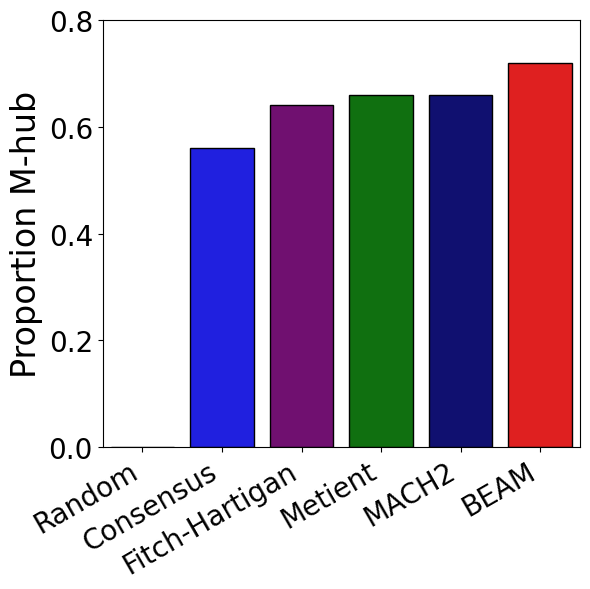

In [70]:
# Create figure
plt.figure(figsize=(6, 6))
fs=24

colors = {
        "BEAM": "red",
        "Random": "darkgrey",
        "Fitch-Hartigan": "purple",
        "Metient": "green",
        "Consensus": "blue",
        "MACH2": "navy",
    }

ax = sns.barplot(
    data=proportion_df,
    x="Method",
    y="Proportion M-Hub",
    hue="Method",
    palette=colors,
    edgecolor="black"
)

# Formatting
ax.set_xlabel("", fontsize=fs)
ax.set_ylabel("Proportion M-hub", fontsize=fs)
ax.set_ylim(0, 0.8)
ax.tick_params(labelsize=fs-4)
plt.xticks(rotation=30, ha="right")
ax.tick_params(axis='x', labelsize=fs-4)

plt.tight_layout()
# plt.savefig(f"{indir}/m_hub_proportions_barplot.pdf")
plt.show()
plt.close()

In [105]:
beam_log_files = glob.glob(os.path.join(indir, "beam_gtr", "*", "combined.log"))
print(len(beam_log_files))

tissues = ['P', 'M1', 'M2', 'M3']

trait_clock_rates = {}
trait_clock_rate_means = {}
relative_rates = {}
for tissue in tissues:
    for tissue2 in tissues:
        if tissue != tissue2:
            relative_rates[f"{tissue}_{tissue2}"] = {}

for file in beam_log_files:
    simname = os.path.basename(os.path.dirname(file))
    df = pd.read_csv(file, sep="\t", comment='#')
    trait_clock_rates[simname] = df['traitClockRate'].values.tolist()
    trait_clock_rate_means[simname] = np.mean(df['traitClockRate'].values.tolist())
    
    cols_to_keep = [colname for colname in df.columns if 'tissueSubstModelLogger.relGeoRate_' in colname]
    df = df[cols_to_keep]
    df.columns = [colname.replace('tissueSubstModelLogger.relGeoRate_', '') for colname in df.columns]
    for colname in df.columns:
        relative_rates[colname][simname] = df[colname].values.tolist()

relative_rate_means = {}
for rate in relative_rates:
    relative_rate_means[rate] = {}
    for simname in relative_rates[rate]:
        relative_rate_means[rate][simname] = np.mean(relative_rates[rate][simname])

overall_relative_rate_means = {}
for rate in relative_rate_means:
    overall_relative_rate_means[rate] = np.mean(list(relative_rate_means[rate].values()))

df_trait_clock_rate_means = pd.DataFrame({"simname": list(trait_clock_rate_means.keys()), "trait_clock_rate_mean": list(trait_clock_rate_means.values())})

square_mat = pd.DataFrame(0, index=tissues, columns=tissues)
for rate_key, val in overall_relative_rate_means.items():
    t1, t2 = rate_key.split("_")
    square_mat.loc[t1, t2] = val


50


/tmp/ipykernel_3330322/306408845.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.21636935134410534' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  square_mat.loc[t1, t2] = val
/tmp/ipykernel_3330322/306408845.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6673800173440506' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  square_mat.loc[t1, t2] = val
/tmp/ipykernel_3330322/306408845.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.21772251877035806' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  square_mat.loc[t1, t2] = val
/tmp/ipykernel_3330322/306408845.py:41: FutureWarning: Setting an item of inc

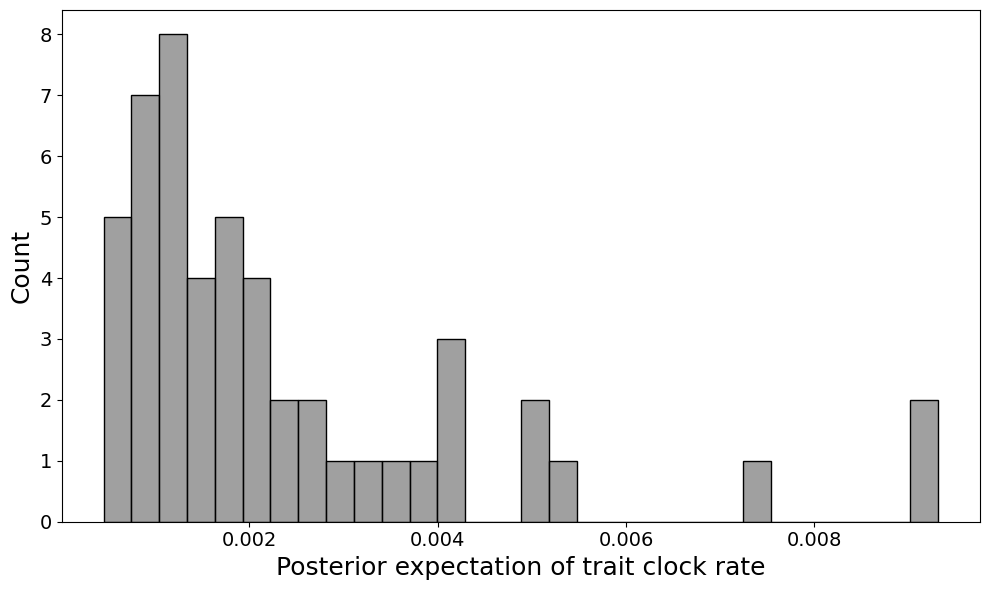

In [106]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_trait_clock_rate_means,
    x="trait_clock_rate_mean",
    bins=30,
    kde=False, 
    edgecolor="black",
    color="grey"
)

plt.xlabel("Posterior expectation of trait clock rate", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("", fontsize=20)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()
plt.close()

In [109]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    square_mat,
    cmap="YlOrRd",
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Mean posterior expected relative migration rate",}
)

plt.title("", fontsize=fs)
plt.xlabel("Target", fontsize=fs)
plt.ylabel("Source", fontsize=fs)
plt.xticks(rotation=0, ha="right", fontsize=fs-4)
plt.yticks(rotation=0, fontsize=fs-4)

plt.tight_layout()
plt.savefig(f"{indir}/mean_relative_migration_rates_heatmap.pdf")
# plt.show()
plt.close()